In [1]:
import scipy.io
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
folder_path = "CWRU/12k data/3_hp_load"
all_data_frames = [] # We use a list to stack our uneven data blocks

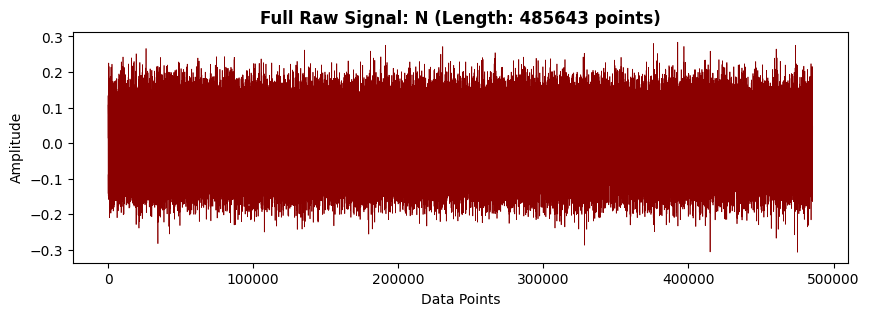

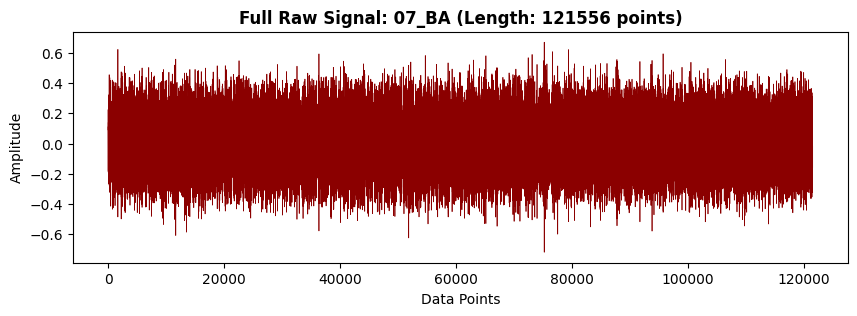

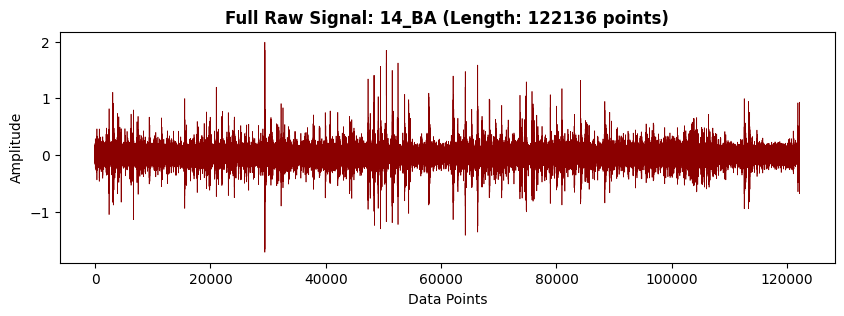

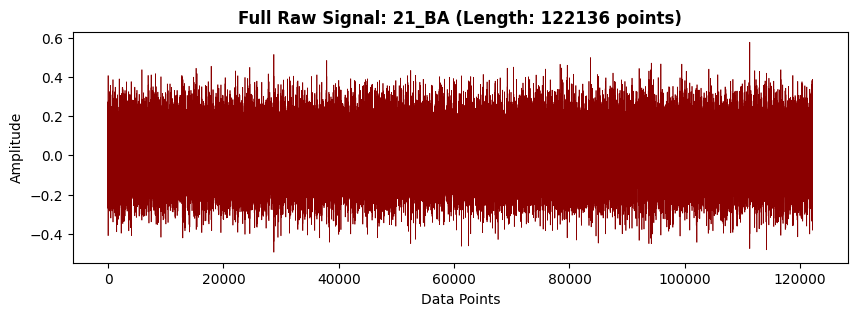

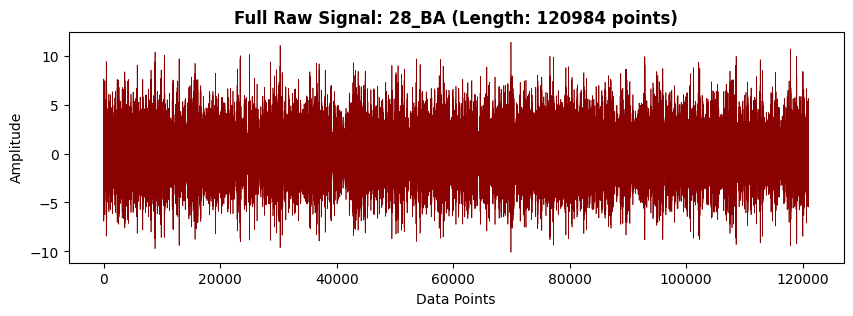

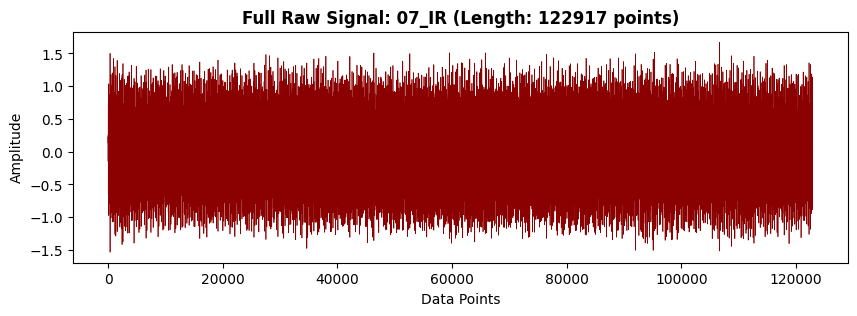

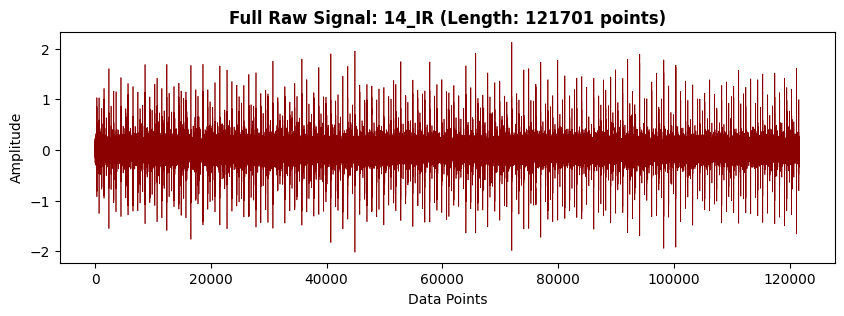

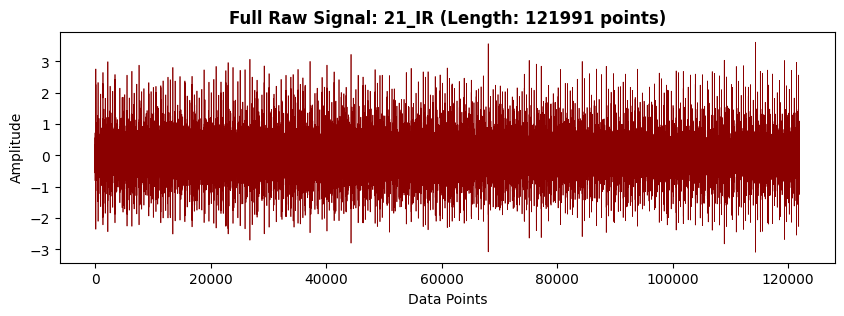

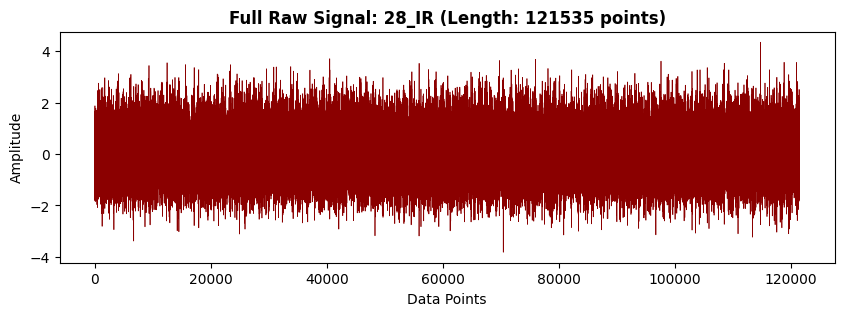

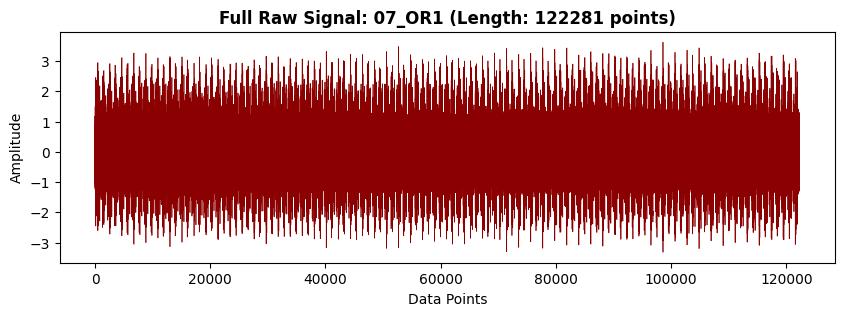

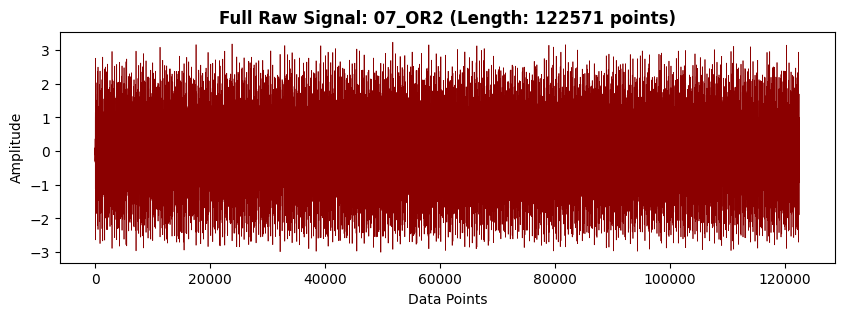

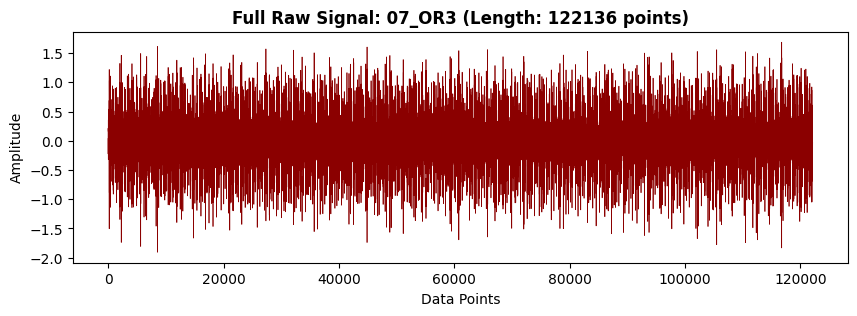

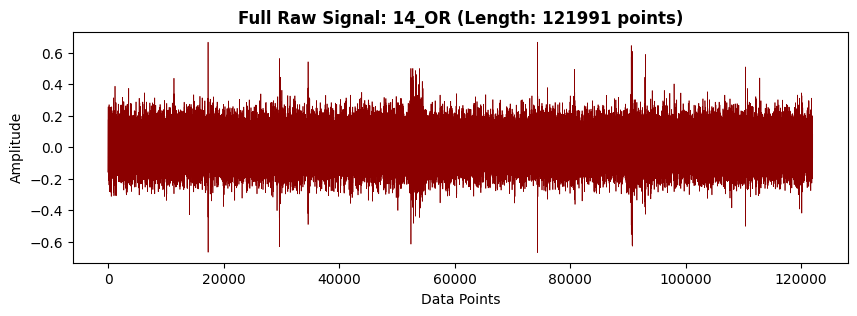

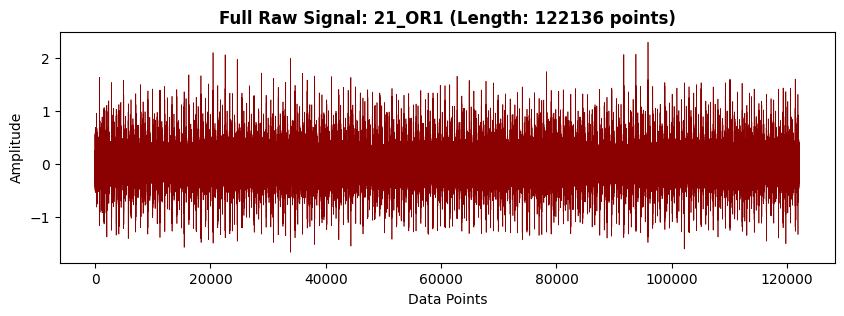

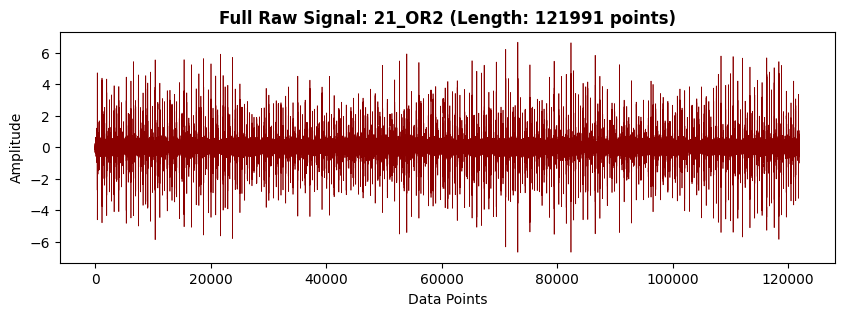

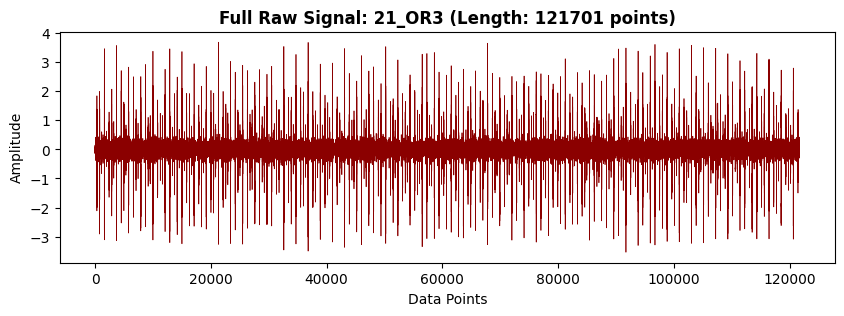

In [3]:
for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith('.mat'):
            path = os.path.join(root, file)
            name = file.replace('.mat', '')
            mat_data = scipy.io.loadmat(path)
            
            for key in mat_data.keys():
                if 'DE_time' in key:
                    signal = mat_data[key].flatten()

                    plt.figure(figsize=(10,3))
                    plt.plot(signal, color='darkred', linewidth=0.5)
                    # Notice the title will now show you exactly how many points are in each unique file!
                    plt.title(f"Full Raw Signal: {name} (Length: {len(signal)} points)", fontweight='bold')
                    plt.xlabel("Data Points")
                    plt.ylabel("Amplitude")
                    plt.show()

                    temp_df = pd.DataFrame({'DE_data': signal, 'fault': name})
                    all_data_frames.append(temp_df)
                    break

In [4]:
df_long = pd.concat(all_data_frames, ignore_index=True)
print(f"\nSuccess! 100% of data retained. Total points: {len(df_long)}")


Success! 100% of data retained. Total points: 2315406


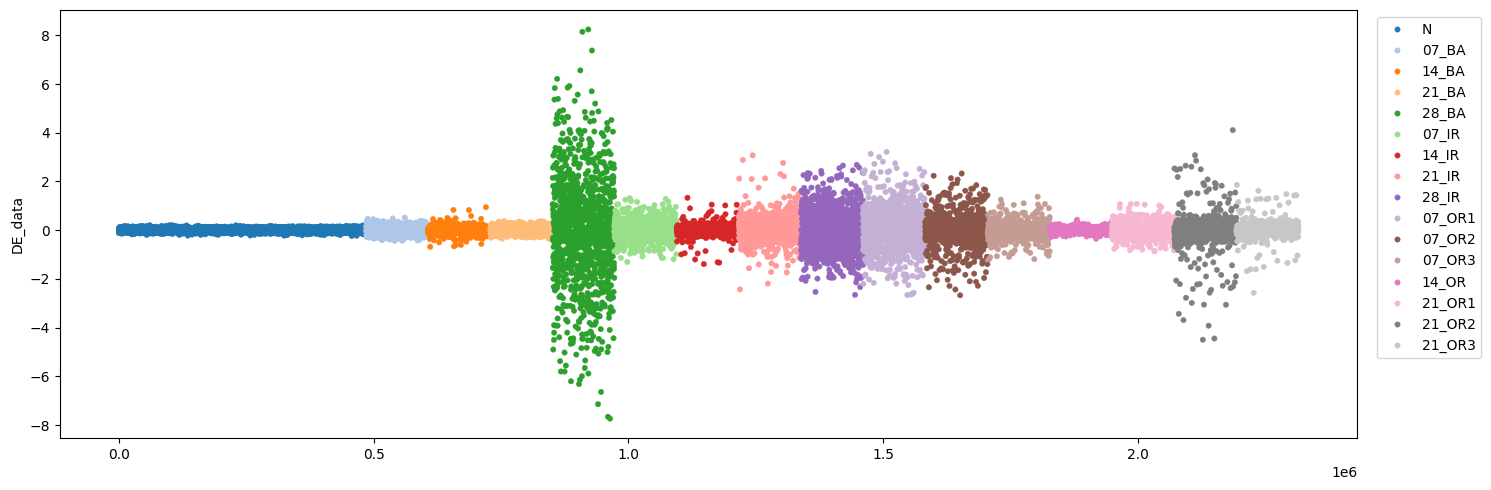

In [5]:
plt.figure(figsize=(15, 5))
sns.scatterplot(
    data=df_long.iloc[:: 100, :],
    x=np.arange(0, len(df_long), 100), 
    y='DE_data', 
    hue='fault',
    palette='tab20',
    s=15,
    edgecolor=None
)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [7]:
df_long.to_parquet('CWRU_raw_data_3_load.parquet', engine='pyarrow', index=False)
print("File saved successfully as CWRU_raw_data_3_load.parquet")


File saved successfully as CWRU_raw_data_3_load.parquet


In [8]:
print(df_long.head())
print(df_long.tail())

    DE_data fault
0  0.014603     N
1  0.054449     N
2  0.107646     N
3  0.133722     N
4  0.112652     N
          DE_data   fault
2315401  0.050355  21_OR3
2315402  0.176242  21_OR3
2315403  0.114517  21_OR3
2315404  0.105583  21_OR3
2315405  0.207105  21_OR3


In [9]:
df=pd.read_parquet('CWRU_raw_data_3_load.parquet')

In [10]:
df

,DE_data,fault
0,0.014603,N
1,0.054449,N
2,0.107646,N
3,0.133722,N
4,0.112652,N
...,...,...
2315401,0.050355,21_OR3
2315402,0.176242,21_OR3
2315403,0.114517,21_OR3
2315404,0.105583,21_OR3
